# MAPLE event selection (cafpyana)

Loads a maple `.df` (produced with `analysis_village/maple/configs/maple_evt*.py`),
applies/inspects the MAPLE 1muNp cut chain, and builds the sBruce-equivalent
variables and truth-level efficiency (`Pass_cut`) exactly as CAFANA-MAPLE does.

Run from the cafpyana root after `source setup.sh`.

In [1]:
import os, sys

os.environ["PYTHONPATH"] = (
    "/cvmfs/larsoft.opensciencegrid.org/spack-fnal-v1.0.0/opt/spack/linux-x86_64_v2/root-6.28.12-vgs6mjswsg36hl3oarsrsyc2dcua6khe/lib/root:"
    "/cvmfs/larsoft.opensciencegrid.org/spack-fnal-v1.0.0/opt/spack/linux-x86_64_v2/py-numpy-1.26.4-bjfwdigla2ihyygih63foelrl4jedvx2/lib/python3.10/site-packages:"
    "/cvmfs/larsoft.opensciencegrid.org/spack-fnal-v1.0.0/opt/spack/linux-x86_64_v2/python-venv-1.0-cgtupqvpxtthincoh5fq6qsmk2q5wdhq/lib/python3.10/site-packages:"
    "/cvmfs/fermilab.opensciencegrid.org/packages/common/sam-web-client/3.6/linux-almalinux9-x86_64_v2-gcc-11.4.1-wqczc57sjch75cf6ztddpvcums6etwsw/python:"
    "/cvmfs/fermilab.opensciencegrid.org/packages/common/py-requests/2.31.0/linux-almalinux9-x86_64_v2-gcc-11.4.1-u4i6ukxy5ooe5wh3k74vzctgmhrn3d67/lib/python3.9/site-packages:"
    "/cvmfs/fermilab.opensciencegrid.org/packages/common/py-urllib3/2.0.6/linux-almalinux9-x86_64_v2-gcc-11.4.1-bmjk2ygp2lx6vdxyxsstxlyoglcjn5sb/lib/python3.9/site-packages:"
    "/cvmfs/fermilab.opensciencegrid.org/packages/common/py-charset-normalizer/3.3.0/linux-almalinux9-x86_64_v2-gcc-11.4.1-3acqio4thtvyb72ppli3n37l6er6bl4y/lib/python3.9/site-packages:"
    "/cvmfs/fermilab.opensciencegrid.org/packages/common/py-idna/3.4/linux-almalinux9-x86_64_v2-gcc-11.4.1-4z2dtzk7j5wbnqvv3tbaxjustzsbuy4q/lib/python3.9/site-packages:"
    "/cvmfs/fermilab.opensciencegrid.org/packages/common/py-certifi/2023.7.22/linux-almalinux9-x86_64_v2-gcc-11.4.1-pvizh2z2a4ygtl76pqwkexxeqd4qwhws/lib/python3.9/site-packages:"
    "/exp/icarus/app/users/nsommagg/cafpyana_gump"
)

sys.path = os.environ["PYTHONPATH"].split(":") + sys.path

In [2]:
sys.path.insert(0, "/exp/icarus/app/users/nsommagg/cafpyana_gump/analysis_village/maple")
sys.path.insert(0, "/exp/icarus/app/users/nsommagg/cafpyana_gump/analysis_village/gump")
sys.path.insert(0, "/exp/icarus/app/users/nsommagg/cafpyana_gump") 

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis_village.gump.kinematics
import analysis_village.gump.syst
import analysis_village.gump.loaddf as loaddf

In [3]:
import h5py
import pandas as pd

DF_DIR = "/exp/icarus/data/users/nsommagg/df_store_nosel/"
DF_NAME = "n_ICARUSRun4_SpringMCOverlay_nosel_0.df"

#DF_DIR = "/exp/sbnd/data/users/gputnam/MAPLE/sbn-rewgted-14/"
#DF_NAME = "ICARUSRun4_SpringMCOverlay_rewgt_0.df"

DF = DF_DIR + DF_NAME

#with h5py.File(DF, "r") as f:
#    print(f.keys())

d0 = pd.read_hdf(DF, "evt_0")
print(list(d0.columns))
d1 = pd.read_hdf(DF, "mcnu_0")
print(list(d1.columns))

#file_list = [DF]

#df,_,_ = loaddf.loadl(file_list, detector="ICARUS Run4", include_syst=False, lightmem=True)

columns_evt = ['nu_E','maxcut','tmatch_idx','tmatch_eff','maple_sel','Reco_class']
columns_nu = ['ind','is_1muNp_maple','nu_E','mu_length']

def load_df(fname, table, columns=None):
    with h5py.File(fname, "r") as f:
        keys = [k for k in f.keys() if k.rsplit("_", 1)[0] == table]
    if not keys:
        return None
    dfs = []
    for k in sorted(keys, key=lambda k: int(k.rsplit("_", 1)[1])):
        d = pd.read_hdf(fname, k)
        if columns is not None:
            d = d[columns]
        dfs.append(d)
    return pd.concat(dfs)

['slc_vtx_x', 'slc_vtx_y', 'slc_vtx_z', 'charge_center_z', 'nu_score', 'tmatch_idx', 'tmatch_eff', 'tmatch_pur', 'nu_E', 'true_pdg', 'true_iscc', 'true_isnc', 'true_iscosmic', 'true_genie_mode', 'true_vtx_x', 'true_vtx_y', 'true_vtx_z', 'ismc', 'slice_index', 'detector', 'Run', 'cryo_light', 'flash_maxpe_cryo0', 'flash_maxpe_cryo1', 'flash_maxpe', 'crthit', 'cut_sanity', 'cut_fv', 'cut_crthit', 'slice_cryo', 'cut_cryo', 'cut_contained', 'cut_cathode', 'maple_presel', 'n_proton', 'n_shower', 'n_other', 'has_muon', 'cut_np', 'cut_0shwother', 'mu_chi2_of_prot_cand', 'prot_chi2_of_prot_cand', 'mu_chi2cafana_of_prot_cand', 'prot_chi2cafana_of_prot_cand', 'mu_chi2lo_of_prot_cand', 'prot_chi2lo_of_prot_cand', 'mu_chi2hi_of_prot_cand', 'prot_chi2hi_of_prot_cand', 'mu_chi22lo_of_prot_cand', 'prot_chi22lo_of_prot_cand', 'mu_chi22hi_of_prot_cand', 'prot_chi22hi_of_prot_cand', 'mu_chi2smear5_of_prot_cand', 'prot_chi2smear5_of_prot_cand', 'mu_chi2smear13_of_prot_cand', 'prot_chi2smear13_of_prot_can

In [4]:
evt = load_df(DF, "evt", columns_evt)
mcnu = load_df(DF, "mcnu", columns_nu)

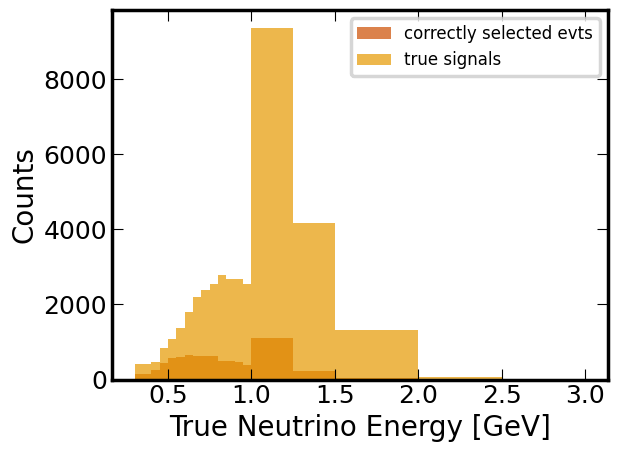

In [14]:
sel_numu = mcnu[(mcnu.is_1muNp_maple) & (mcnu.mu_length > 40) & (mcnu.mu_length < 400)].copy()
sel_evt = evt[(evt.maple_sel) & (evt.Reco_class == 1)].copy()
fig, ax = plt.subplots()
enu_bins = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0])
ax.hist(sel_evt.nu_E, bins=enu_bins, histtype='stepfilled', alpha=0.7, label='correctly selected evts')
ax.hist(sel_numu.nu_E, bins=enu_bins, histtype='stepfilled', alpha=0.7, label='true signals')
ax.legend(fontsize=12)
ax.set_xlabel('True Neutrino Energy [GeV]')
ax.set_ylabel('Counts')
fig.savefig('true_neutrino_energy.pdf', format='pdf', bbox_inches='tight')

In [13]:
print(len(mcnu[mcnu.is_1muNp_maple]), 'true signals')
print(len(mcnu[(mcnu.is_1muNp_maple) & (mcnu.mu_length > 40) & (mcnu.mu_length < 400)]), 'true signals + mu length min/max cond')
print(len(evt[(evt.maple_sel) & (evt.Reco_class == 1)]), 'reco signals')
print('efficiency: ', len(evt[(evt.maple_sel) & (evt.Reco_class == 1)]) / len(mcnu[mcnu.is_1muNp_maple]))
print('efficiency mu min/max length: ', len(evt[(evt.maple_sel) & (evt.Reco_class == 1)]) / len(mcnu[(mcnu.is_1muNp_maple) & (mcnu.mu_length > 40) & (mcnu.mu_length < 400)]))

51330 true signals
38759 true signals + mu length min/max cond
7780 reco signals
efficiency:  0.15156828365478278
efficiency mu min/max length:  0.20072757295079852


Pass_cut
1.0       600
2.0       347
3.0      3801
4.0       373
5.0      1441
6.0      2651
7.0      5904
8.0      9434
9.0       389
10.0    13819
Name: count, dtype: int64


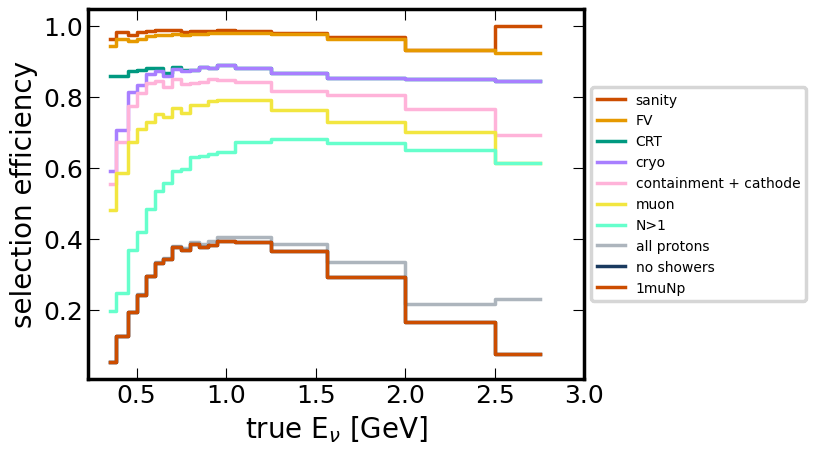

In [21]:
nus = mcnu[(mcnu.is_1muNp_maple) & (mcnu.mu_length > 40) & (mcnu.mu_length < 400)].copy()
# match slices to true interactions: same event, tmatch idx == nu index, tmatch eff >= 0.5
evt_eff = evt[~(evt.tmatch_eff < 0.5)].reset_index()
key = [c for c in ("__ntuple", "entry") if c in evt_eff.columns]
evt_eff["tidx"] = evt_eff.tmatch_idx.astype(int)
maxcut = evt_eff.groupby(key + ["tidx"]).maxcut.max()

n = nus.reset_index()
lookup = pd.MultiIndex.from_arrays([n[k] for k in key] + [n["ind"].astype(int)])
n["Pass_cut"] = maxcut.reindex(lookup).fillna(1).clip(lower=1).values
print(n.Pass_cut.value_counts().sort_index())

#fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
fig, ax = plt.subplots()
#axs[0].hist(n.Pass_cut, bins=np.arange(0.5, 12)); axs[0].set_xlabel("Pass_cut (max cut reached)")
#enu_bins = np.linspace(0, 3, 16)
#ctr = (enu_bins[:-1] + enu_bins[1:]) / 2

enu_bins = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0])
#enu_bins = np.array([0.,3])
ctr = 0.5 * (enu_bins[:-1] + enu_bins[1:])
#print(ctr)

den, _ = np.histogram(n.nu_E, bins=enu_bins)

labels = ['sanity', 'FV', 'CRT', 'cryo', 'containment + cathode', 'muon', 'N>1', 'all protons', 'no showers', '1muNp']
for cut_level in range(0,10):
    if cut_level + 1 < 10 :
        num, _ = np.histogram(n.nu_E[n.Pass_cut > cut_level + 1], bins=enu_bins)
    elif cut_level + 1 == 0 :
        num, _ = np.histogram(n.nu_E[n.Pass_cut == cut_level + 1], bins=enu_bins)
    with np.errstate(invalid="ignore"):
        #axs[1].step(ctr, num / den, where="mid",label=labels[cut_level])
        ax.step(ctr, num / den, where="mid",label=labels[cut_level])
        
#axs[1].set_xlabel("true E$_\\nu$ [GeV]"); axs[1].set_ylabel("selection efficiency")
ax.set_xlabel("true E$_\\nu$ [GeV]"); ax.set_ylabel("selection efficiency")
#axs[1].legend()
ax.set_xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)
#fig.tight_layout()
#fig.savefig('eff_cafpyana_prova.pdf', format='pdf', bbox_inches = 'tight')

## Cutflow

In [38]:
cuts = ["cut_sanity", "cut_fv", "cut_crtveto", "cut_cryo", "cut_contained",
        "cut_muon", "cut_np", "cut_0pi", "cut_0shwother"]
labels = ["sanity", "FV", "CRT veto", "cryo-light", "containment",
          "1 muon", "N>1 protons", "0 pions", "0 showers/other"]
mask = pd.Series(True, index=evt.index)
print("%-18s %8s" % ("cut", "slices"))
print("%-18s %8d" % ("all", len(evt)))
for c, l in zip(cuts, labels):
    mask &= evt[c]
    print("%-18s %8d" % (l, mask.sum()))
sel = evt[evt.maple_sel]
print("selected (maple_sel):", len(sel))

cut                  slices
all                34421139


KeyError: 'cut_sanity'

## sBruce variables for selected slices

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
sel = evt[evt.maple_sel]
axs[0,0].hist(sel.recoE, bins=np.linspace(0, 3, 31)); axs[0,0].set_xlabel("recoE [GeV]")
axs[0,1].hist(sel.Muon_length, bins=np.linspace(0, 400, 41)); axs[0,1].set_xlabel("Muon length [cm]")
axs[0,2].hist(sel.Proton_length_leading, bins=np.linspace(0, 100, 41)); axs[0,2].set_xlabel("Leading proton length [cm]")
axs[1,0].hist(sel.deltaPt, bins=np.linspace(0, 1, 26)); axs[1,0].set_xlabel(r"$\delta p_T$ [GeV]")
axs[1,1].hist(sel.T3D_angle_mup, bins=np.linspace(-1, 1, 26)); axs[1,1].set_xlabel(r"cos $\theta_{\mu p}$")
axs[1,2].hist(sel.Number_protons, bins=np.arange(0.5, 8)); axs[1,2].set_xlabel("N protons")
fig.tight_layout()

## PID: cafpyana-recomputed (gump-style) vs CAFANA-compat chi2

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
mu = evt[evt.cut_muon]
axs[0].scatter(mu.Muon_chi2mu_cafana, mu.Muon_chi2mu_cafpyana, s=2)
axs[0].plot([0, 120], [0, 120], "r--"); axs[0].set_xlabel(r"$\chi^2_\mu$ (cafana)"); axs[0].set_ylabel(r"$\chi^2_\mu$ (cafpyana)")
axs[1].scatter(mu.Muon_chi2pro_cafana, mu.Muon_chi2pro_cafpyana, s=2)
axs[1].plot([0, 400], [0, 400], "r--"); axs[1].set_xlabel(r"$\chi^2_p$ (cafana)"); axs[1].set_ylabel(r"$\chi^2_p$ (cafpyana)")
fig.tight_layout()

print("selection agreement between PID flavors:")
print("  primary:", evt.maple_sel.sum(), " alt:", evt.maple_sel_alt.sum(),
      " both:", (evt.maple_sel & evt.maple_sel_alt).sum())

## Truth-level efficiency (`Pass_cut`)

Replicates CAFANA `kEff_cuts`: for each true 1muNp interaction, the maximum
cut level reached by any truth-matched slice (tmatch eff >= 0.5).

## Calorimetric variations (chi2 of the muon candidate)

In [ ]:
calovars = [c.replace("Muon_chi2mu_", "") for c in evt.columns
            if c.startswith("Muon_chi2mu_") and c.split("_")[-1] not in ("cafpyana", "cafana")]
if calovars:
    mu = evt[evt.maple_sel]
    print("%-12s %10s %10s" % ("variation", "mean chi2mu", "mean chi2p"))
    print("%-12s %10.2f %10.2f" % ("nominal", mu.Muon_chi2mu_cafpyana.mean(), mu.Muon_chi2pro_cafpyana.mean()))
    for v in calovars:
        print("%-12s %10.2f %10.2f" % (v, mu["Muon_chi2mu_%s" % v].mean(), mu["Muon_chi2pro_%s" % v].mean()))
else:
    print("this production was made with do_calo_syst=False")